<a href="https://colab.research.google.com/github/irsyad-kamil/indonesia-ai-nlpa-summary/blob/bert2bert-model/bert2bert_irsyad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1) Environment Setup
Mount Google Drive and install required libraries.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q transformers datasets evaluate rouge_score

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.1 MB/s eta 0:00:00


## 2) Data Extraction and Sampling
Extract raw data, refresh destination folders, and build train/dev/test samples.

In [3]:
import os

file_path = '/content/drive/MyDrive/Bootcamp/Project 2/liputan6_data.tar.gz'
local_extract_path = '/content/temp_extract'

# Create local directory
os.makedirs(local_extract_path, exist_ok=True)

print(f"Extracting 'canonical' folder to local storage {local_extract_path}...")
# Extract only the canonical directory from the archive
!tar -xzf "{file_path}" -C "{local_extract_path}" liputan6_data/canonical
print("Local extraction finished.")

Extracting 'canonical' folder to local storage /content/temp_extract...
Local extraction finished.


In [4]:
import os
import json
import pandas as pd
import random
from tqdm.notebook import tqdm

def load_and_split_sampled(base_path, total_sample=10000, train_ratio=0.7, dev_ratio=0.1):
    # 1. Kumpulkan SEMUA path file dari folder train asli
    train_dir = os.path.join(base_path, 'train')
    all_files = [os.path.join(train_dir, f) for f in os.listdir(train_dir) if f.endswith('.json')]

    # 2. Acak dan Ambil sesuai limit (10.000)
    random.seed(42)
    random.shuffle(all_files)
    sampled_paths = all_files[:total_sample]

    # 3. Hitung batasan split
    train_end = int(total_sample * train_ratio)
    dev_end = train_end + int(total_sample * dev_ratio)

    splits = {
        'train': sampled_paths[:train_end],
        'dev': sampled_paths[train_end:dev_end],
        'test': sampled_paths[dev_end:]
    }

    results = {}

    for name, paths in splits.items():
        records = []
        for p in tqdm(paths, desc=f"Processing {name}"):
            with open(p, 'r') as f:
                data = json.load(f)
                # Pakai logika join kalimat temanmu yang bagus tadi
                article = " ".join([" ".join(s) for s in data.get('clean_article', [])])
                summary = " ".join([" ".join(s) for s in data.get('clean_summary', [])])

                records.append({
                    'id': data.get('id'),
                    'article': article,
                    'summary': summary
                })
        results[name] = pd.DataFrame(records)

    return results['train'], results['dev'], results['test']

# Eksekusi
base_dir = '/content/drive/MyDrive/Bootcamp/Project 2/liputan6_data/canonical' # Sesuaikan path ekstrakmu
df_train, df_dev, df_test = load_and_split_sampled(base_dir, total_sample=10000)

Processing train:   0%|          | 0/7000 [00:00<?, ?it/s]

Processing dev:   0%|          | 0/1000 [00:00<?, ?it/s]

Processing test:   0%|          | 0/2000 [00:00<?, ?it/s]

In [5]:
# Fungsi untuk menggabungkan list menjadi string tunggal
# Kita tambahkan pengecekan isinstance untuk memastikan hanya memproses data yang berbentuk list
df_train['article'] = df_train['article'].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)
df_train['summary'] = df_train['summary'].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)

# Lakukan hal yang sama untuk df_dev dan df_test jika ada
df_dev['article'] = df_dev['article'].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)
df_dev['summary'] = df_dev['summary'].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)

df_test['article'] = df_test['article'].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)
df_test['summary'] = df_test['summary'].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)

# Cek hasil 1 data teratas
print("Contoh artikel setelah digabung:")
print(df_train['article'].iloc[0][:200] + "...") # Tampilkan 200 karakter pertama saja

Contoh artikel setelah digabung:
Liputan6 . com , Jakarta : Permintaan Anggodo Widjojo untuk menginap di Gedung Dewan Pertimbangan Presiden ( Wantimpres ) , tempat Tim Pencari Fakta kasus Bibit-Chandra ( TPF ) bekerja , tampaknya ter...


In [6]:
# Tentukan folder penyimpanan di Drive
save_path = '/content/drive/MyDrive/Bootcamp/Project 2/processed_data'

# Buat folder jika belum ada
if not os.path.exists(save_path):
    os.makedirs(save_path)

# Simpan ke CSV
df_train.to_csv(f'{save_path}/liputan6_10k_train.csv', index=False)
df_dev.to_csv(f'{save_path}/liputan6_10k_dev.csv', index=False)
df_test.to_csv(f'{save_path}/liputan6_10k_test.csv', index=False)

print(f"Berhasil menyimpan 3 file CSV di: {save_path}")

Berhasil menyimpan 3 file CSV di: /content/drive/MyDrive/Bootcamp/Project 2/processed_data


## 3) EDA

Gabungkan Split

In [7]:
df_train_eda = df_train.copy()
df_dev_eda = df_dev.copy()
df_test_eda = df_test.copy()

df_train_eda["split"] = "train"
df_dev_eda["split"] = "dev"
df_test_eda["split"] = "test"

df_all = pd.concat([df_train_eda, df_dev_eda, df_test_eda], ignore_index=True)
print("Penggabungan Berhasil.")

Penggabungan Berhasil.


In [23]:
df_all.sample(5)

,id,article,summary,split,article_words,article_chars,summary_words,summary_chars,compression_ratio_words,compression_ratio_chars,overlap_token_ratio,overlap_unique_ratio,jaccard_similarity
1555,174825,"Liputan6 . com , Cilacap : Puluhan ton produk ...",Pabrik berbendera PT Jaya Asli itu diduga mela...,train,93,545,33,192,0.354839,0.352294,1.000000,1.000000,0.477273
6791,88551,"Liputan6 . com , Jakarta : Barang bagus , kual...","Di sepanjang Jalan Fachrudin , Tanahabang , Ja...",train,397,2280,33,213,0.083123,0.093421,0.850000,0.842105,0.122137
9293,83052,"Liputan6 . com , Medan : Terpidana mati Ayodyh...",Hukuman mati terhadap Ayodyha Prasad Chaubey y...,test,231,1498,29,192,0.125541,0.128171,0.789474,0.789474,0.144231
1048,167094,"Liputan6 . com , Jakarta : Mahkamah Konstitusi...",Mahkamah Konstitusi menolak uji materi empat p...,train,185,1229,31,203,0.167568,0.165175,0.952381,0.944444,0.202381
2626,32876,"Liputan6 . com , Jakarta : Komisi Nasional Hak...",Komisi Nasional Hak Asasi Manusia akan membuka...,train,314,1921,26,175,0.082803,0.091098,0.937500,0.937500,0.127119


### Distribusi Panjang (Length Distribution)

In [11]:
def count_words(text):
    if pd.isna(text):
        return 0
    return len(str(text).split())

def count_chars(text):
    if pd.isna(text):
        return 0
    return len(str(text))

df_all["article_words"] = df_all["article"].apply(count_words)
df_all["article_chars"] = df_all["article"].apply(count_chars)

df_all["summary_words"] = df_all["summary"].apply(count_words)
df_all["summary_chars"] = df_all["summary"].apply(count_chars)

length_summary = (
    df_all.groupby("split")
    .agg(
        article_words_mean=("article_words", "mean"),
        article_words_median=("article_words", "median"),
        article_words_min=("article_words", "min"),
        article_words_max=("article_words", "max"),

        article_chars_mean=("article_chars", "mean"),
        article_chars_median=("article_chars", "median"),
        article_chars_min=("article_chars", "min"),
        article_chars_max=("article_chars", "max"),

        summary_words_mean=("summary_words", "mean"),
        summary_words_median=("summary_words", "median"),
        summary_words_min=("summary_words", "min"),
        summary_words_max=("summary_words", "max"),

        summary_chars_mean=("summary_chars", "mean"),
        summary_chars_median=("summary_chars", "median"),
        summary_chars_min=("summary_chars", "min"),
        summary_chars_max=("summary_chars", "max"),
    )
    .round(2)
)

display(length_summary)

,article_words_mean,article_words_median,article_words_min,article_words_max,article_chars_mean,article_chars_median,article_chars_min,article_chars_max,summary_words_mean,summary_words_median,summary_words_min,summary_words_max,summary_chars_mean,summary_chars_median,summary_chars_min,summary_chars_max
split,,,,,,,,,,,,,,,,
dev,240.04,201.5,44,1781,1486.44,1264.0,295,11562,30.63,30.0,12,90,196.32,194.0,72,515
test,237.41,200.0,51,1652,1470.08,1236.0,338,10890,30.90,30.0,12,91,197.44,196.0,83,519
train,232.59,196.0,38,1917,1440.36,1218.0,240,12450,31.07,30.0,12,93,198.45,196.0,67,522


Visualisasi distribusi panjang artikel per split

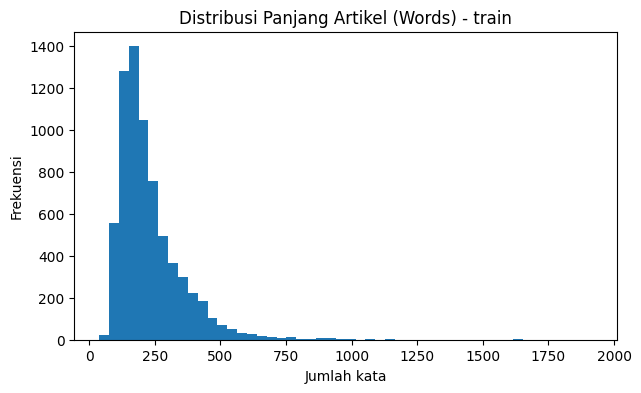

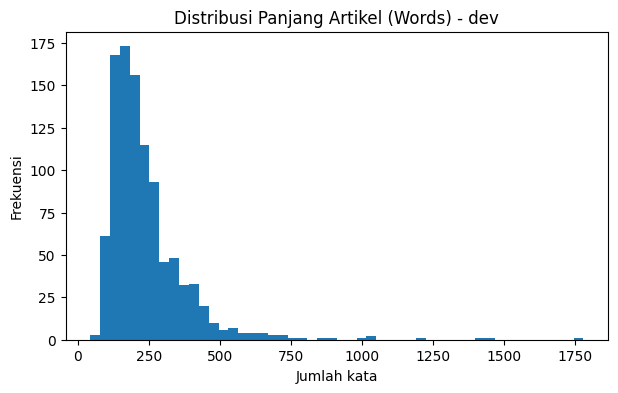

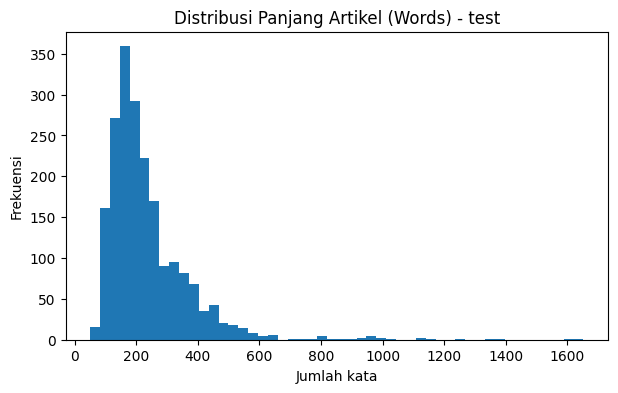

In [12]:
import matplotlib.pyplot as plt
for split in ["train", "dev", "test"]:
    subset = df_all[df_all["split"] == split]

    plt.figure(figsize=(7, 4))
    plt.hist(subset["article_words"], bins=50)
    plt.title(f"Distribusi Panjang Artikel (Words) - {split}")
    plt.xlabel("Jumlah kata")
    plt.ylabel("Frekuensi")
    plt.show()

Visualisasi distribusi panjang summary per split

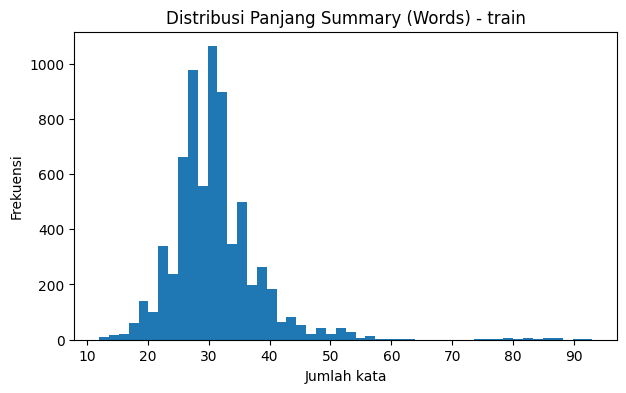

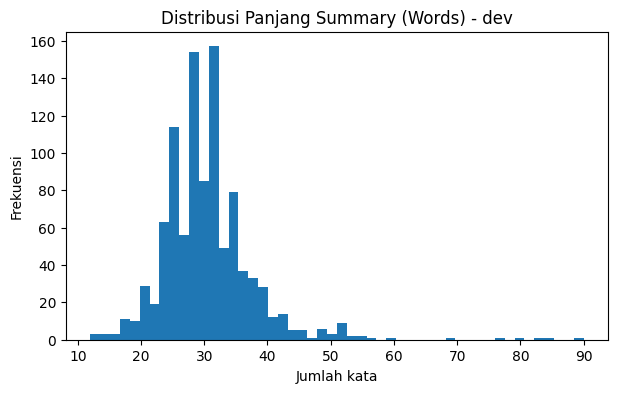

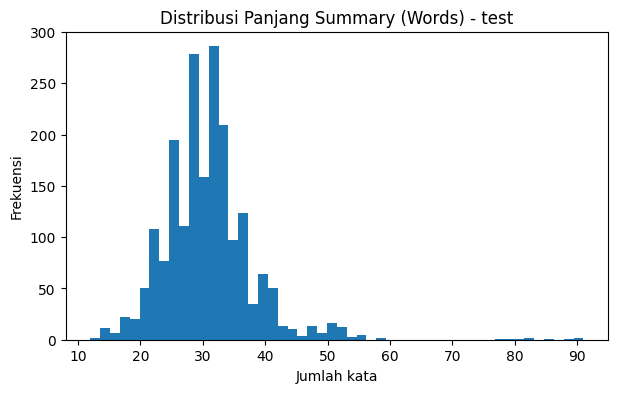

In [13]:
for split in ["train", "dev", "test"]:
    subset = df_all[df_all["split"] == split]

    plt.figure(figsize=(7, 4))
    plt.hist(subset["summary_words"], bins=50)
    plt.title(f"Distribusi Panjang Summary (Words) - {split}")
    plt.xlabel("Jumlah kata")
    plt.ylabel("Frekuensi")
    plt.show()

### Rasio Kompresi (Compression Ratio)

In [14]:
df_all["compression_ratio_words"] = df_all["summary_words"] / df_all["article_words"]
df_all["compression_ratio_chars"] = df_all["summary_chars"] / df_all["article_chars"]

compression_summary = (
    df_all.groupby("split")
    .agg(
        compression_words_mean=("compression_ratio_words", "mean"),
        compression_words_median=("compression_ratio_words", "median"),
        compression_words_min=("compression_ratio_words", "min"),
        compression_words_max=("compression_ratio_words", "max"),

        compression_chars_mean=("compression_ratio_chars", "mean"),
        compression_chars_median=("compression_ratio_chars", "median"),
        compression_chars_min=("compression_ratio_chars", "min"),
        compression_chars_max=("compression_ratio_chars", "max"),
    )
    .round(4)
)

display(compression_summary)

,compression_words_mean,compression_words_median,compression_words_min,compression_words_max,compression_chars_mean,compression_chars_median,compression_chars_min,compression_chars_max
split,,,,,,,,
dev,0.1578,0.1398,0.0163,1.0000,0.1639,0.1480,0.0164,1.0000
test,0.1615,0.1458,0.0180,1.0000,0.1675,0.1511,0.0180,1.0000
train,0.1649,0.1491,0.0136,1.0233,0.1708,0.1539,0.0141,0.9981


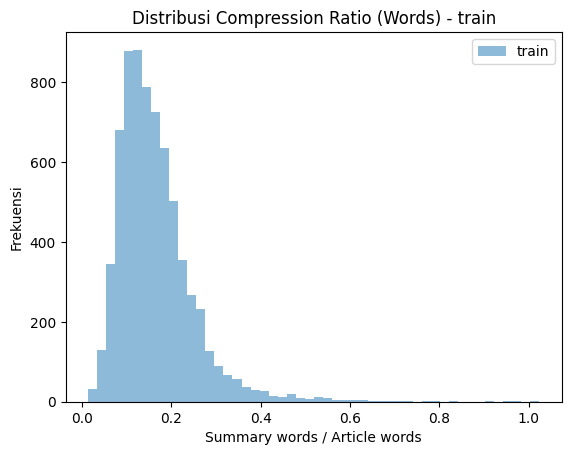

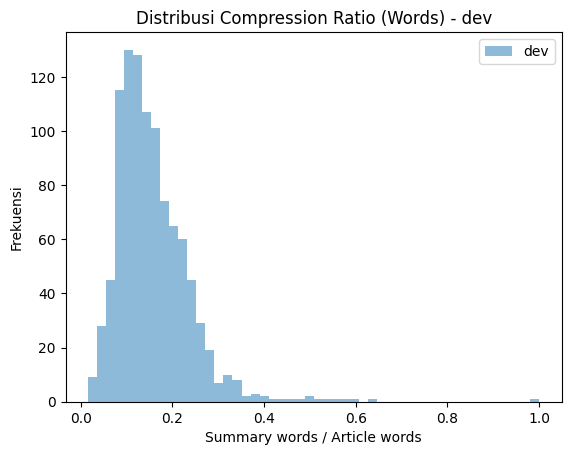

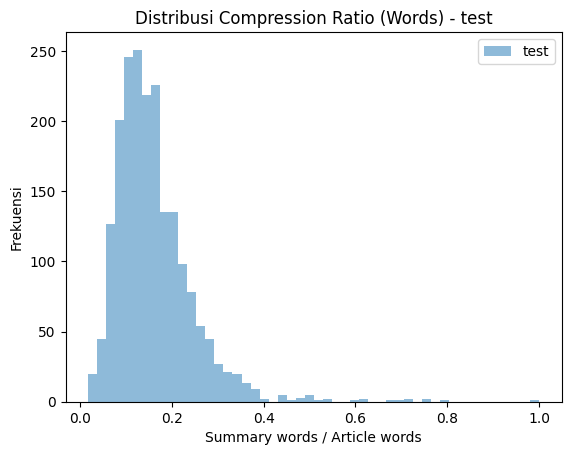

In [15]:
for split in ["train", "dev", "test"]:
    subset = df_all[df_all["split"] == split]

    plt.title(f"Distribusi Compression Ratio (Words) - {split}")
    plt.hist(subset["compression_ratio_words"], bins=50, alpha=0.5, label=split)
    plt.xlabel("Summary words / Article words")
    plt.ylabel("Frekuensi")
    plt.legend()
    plt.show()

### Word Overlap (N-Gram Overlap)

In [19]:
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords")

stop_words = set(stopwords.words("indonesian"))

def simple_tokenize(text):
    if pd.isna(text):
        return []

    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z0-9À-ÿ؀-ۿ\u00C0-\u024F\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()

    # buang stopwords
    tokens = [tok for tok in tokens if tok not in stop_words]

    return tokens

def get_ngrams(tokens, n=1):
    return zip(*[tokens[i:] for i in range(n)])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [21]:
import re

def calc_source_overlap(article, summary):
    article_tokens = simple_tokenize(article)
    summary_tokens = simple_tokenize(summary)

    if len(article_tokens) == 0 or len(summary_tokens) == 0:
        return pd.Series({
            "overlap_token_ratio": 0.0,
            "overlap_unique_ratio": 0.0,
            "jaccard_similarity": 0.0
        })

    article_token_set = set(article_tokens)
    summary_token_set = set(summary_tokens)

    overlap_token_ratio = sum(tok in article_token_set for tok in summary_tokens) / len(summary_tokens)
    overlap_unique_ratio = len(summary_token_set & article_token_set) / len(summary_token_set)
    jaccard_similarity = len(summary_token_set & article_token_set) / len(summary_token_set | article_token_set)

    return pd.Series({
        "overlap_token_ratio": overlap_token_ratio,
        "overlap_unique_ratio": overlap_unique_ratio,
        "jaccard_similarity": jaccard_similarity
    })

overlap_features = df_all.apply(
    lambda row: calc_source_overlap(row["article"], row["summary"]),
    axis=1
)

df_all = pd.concat([df_all, overlap_features], axis=1)

In [22]:
overlap_summary = (
    df_all.groupby("split")
    .agg(
        overlap_token_mean=("overlap_token_ratio", "mean"),
        overlap_token_median=("overlap_token_ratio", "median"),
        overlap_token_min=("overlap_token_ratio", "min"),
        overlap_token_max=("overlap_token_ratio", "max"),

        overlap_unique_mean=("overlap_unique_ratio", "mean"),
        overlap_unique_median=("overlap_unique_ratio", "median"),
        overlap_unique_min=("overlap_unique_ratio", "min"),
        overlap_unique_max=("overlap_unique_ratio", "max"),

        jaccard_mean=("jaccard_similarity", "mean"),
        jaccard_median=("jaccard_similarity", "median"),
        jaccard_min=("jaccard_similarity", "min"),
        jaccard_max=("jaccard_similarity", "max"),
    )
    .round(4)
)

display(overlap_summary)

,overlap_token_mean,overlap_token_median,overlap_token_min,overlap_token_max,overlap_unique_mean,overlap_unique_median,overlap_unique_min,overlap_unique_max,jaccard_mean,jaccard_median,jaccard_min,jaccard_max
split,,,,,,,,,,,,
dev,0.8596,0.8750,0.2000,1.0,0.8516,0.8667,0.2000,1.0,0.1799,0.1635,0.0161,1.0000
test,0.8638,0.8889,0.2353,1.0,0.8557,0.8824,0.2500,1.0,0.1851,0.1683,0.0200,1.0000
train,0.8659,0.8947,0.1111,1.0,0.8582,0.8824,0.0769,1.0,0.1885,0.1719,0.0073,0.9783


### Top unigram pada artikel (train)

In [28]:
from collections import Counter
from itertools import chain

article_tokens_train = list(chain.from_iterable(
    df_train["article"].apply(simple_tokenize)
))

top20_unigram_article = pd.DataFrame(
    Counter(article_tokens_train).most_common(20),
    columns=["unigram", "freq"]
)

display(top20_unigram_article)

,unigram,freq
0,com,6257
1,jakarta,6244
2,liputan6,6170
3,warga,4528
4,tim,4138
5,rumah,3488
6,baca,3265
7,polisi,3051
8,1,2784
9,indonesia,2743


### Top bigram pada artikel (train)

In [30]:
article_bigrams_train = Counter(
    chain.from_iterable(
        get_ngrams(tokens, 2)
        for tokens in df_train["article"].apply(simple_tokenize)
    )
)

top20_bigram_article = pd.DataFrame(
    [(" ".join(bg), freq) for bg, freq in article_bigrams_train.most_common(20)],
    columns=["bigram", "freq"]
)

display(top20_bigram_article)

,bigram,freq
0,liputan6 com,6148
1,com jakarta,2353
2,liputan 6,1440
3,6 sctv,1369
4,tim liputan,1319
5,rumah sakit,950
6,jawa barat,843
7,jawa timur,732
8,jakarta pusat,495
9,jakarta selatan,429


## 4) Cleaning

Fokuslah pada "Data Quality Cleaning", bukan "Word Stripping". Contohnya:

Hapus Karakter Spesial Berlebihan: Misalnya `\n`, `\t`, atau sisa-sisa tag HTML jika ada.

Hapus Spasi Ganda: Agar tokenisasi lebih hemat.

Hapus Artikel Sangat Pendek: Jika ada artikel yang cuma 1-2 kata, sebaiknya dibuang karena tidak ada gunanya diringkas.

In [31]:
def clean_text(text):
    # 1. Hapus sisa-sisa tag HTML
    text = re.sub(r'<.*?>', '', text)

    # 2. Ganti \n (newline), \t (tab), dan \r dengan satu spasi
    text = text.replace('\n', ' ').replace('\t', ' ').replace('\r', ' ')

    # 3. Hapus spasi ganda atau berlebih dan whitespace di awal/akhir
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Terapkan fungsi cleaning ke dataset
for df in [df_train, df_dev, df_test]:
    df['article'] = df['article'].apply(clean_text)
    df['summary'] = df['summary'].apply(clean_text)

# 4. Hapus artikel yang sangat pendek (kurang dari atau sama dengan 2 kata)
print(f"Jumlah data train sebelum filter: {len(df_train)}")
df_train = df_train[df_train['article'].str.split().str.len() > 2]
df_dev = df_dev[df_dev['article'].str.split().str.len() > 2]
df_test = df_test[df_test['article'].str.split().str.len() > 2]
print(f"Jumlah data train setelah filter: {len(df_train)}")

Jumlah data train sebelum filter: 7000
Jumlah data train setelah filter: 7000


## 5) Tokenization

In [33]:
from transformers import BertTokenizer

# Inisialisasi Tokenizer
model_checkpoint = "cahya/bert2bert-indonesian-summarization"
tokenizer = BertTokenizer.from_pretrained(model_checkpoint)

def preprocess_function(examples):
    # 1. Tokenisasi Artikel (Input)
    model_inputs = tokenizer(
        examples["article"],
        max_length=512,
        padding="max_length",
        truncation=True
    )

    # 2. Tokenisasi Ringkasan (Target) - Langsung gunakan parameter text_target
    labels = tokenizer(
        text_target=examples["summary"],
        max_length=128,
        padding="max_length",
        truncation=True
    )

    # Masukkan input_ids dari hasil tokenisasi ringkasan ke kolom 'labels'
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

# Catatan: Untuk menjalankan fungsi ini dengan cepat pada DataFrame,
# kita sebaiknya mengubah DataFrame ke format Dataset Hugging Face.
from datasets import Dataset

train_dataset = Dataset.from_pandas(df_train)
dev_dataset = Dataset.from_pandas(df_dev)
test_dataset = Dataset.from_pandas(df_test)

# Jalankan Tokenisasi (Gunakan batch untuk kecepatan)
tokenized_train = train_dataset.map(preprocess_function, batched=True)
tokenized_dev = dev_dataset.map(preprocess_function, batched=True)
tokenized_test = test_dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

## 6) Training

### Inisialisasi Model BERT2BERT

In [50]:
from transformers import EncoderDecoderModel, GenerationConfig

# 1. Muat ulang model agar config-nya bersih kembali (reset)
model = EncoderDecoderModel.from_pretrained(model_checkpoint)

# 2. Atur parameter arsitektur (INI WAJIB, tapi bukan tuning)
model.config.decoder_start_token_id = tokenizer.cls_token_id
model.config.eos_token_id = tokenizer.sep_token_id
model.config.pad_token_id = tokenizer.pad_token_id
model.config.vocab_size = model.config.encoder.vocab_size

# 3. Atur parameter generasi di tempat yang SEHARUSNYA (generation_config)
# Ini adalah versi DEFAULT (tanpa beam search, tanpa penalty)
model.generation_config = GenerationConfig.from_model_config(model.config)
model.generation_config.max_length = 128
model.generation_config.min_length = 10
model.generation_config.num_beams = 1        # Default (Greedy Search)
model.generation_config.early_stopping = False

# 4. Pastikan tidak ada sisa parameter 'tuning' yang nyangkut di config utama
# Kita hapus manual untuk menghindari ValueError tadi
parameters_to_clear = ['max_length', 'min_length', 'early_stopping', 'num_beams', 'length_penalty', 'no_repeat_ngram_size']
for param in parameters_to_clear:
    if hasattr(model.config, param):
        delattr(model.config, param)

Loading weights:   0%|          | 0/523 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.bert.embeddings.word_embeddings.weight to decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie decoder.cls.predictions.bias to decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
EncoderDecoderModel LOAD REPORT from: cahya/bert2bert-indonesian-summarization
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
encoder.embeddings.position_ids      | UNEXPECTED |  | 
decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you

### Metrik Evaluasi (ROUGE Score)

In [51]:
import evaluate
import numpy as np

rouge = evaluate.load("rouge")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    # 1. Bersihkan predictions dari angka yang mungkin di luar jangkauan vocab
    # (Terkadang model yang belum matang menghasilkan angka aneh)
    predictions = np.where(predictions < tokenizer.vocab_size, predictions, tokenizer.pad_token_id)

    # 2. Decode predictions
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)

    # 3. Ganti -100 di labels dengan pad_token_id agar tidak Overflow
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # 4. Pembersihan sederhana (trim whitespace)
    decoded_preds = [pred.strip() for pred in decoded_preds]
    decoded_labels = [label.strip() for label in decoded_labels]

    # 5. Hitung ROUGE
    result = rouge.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)

    return {k: round(v, 4) for k, v in result.items()}

### Konfigurasi Training (TrainingArguments)

In [56]:
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer, DataCollatorForSeq2Seq

# Pengaturan folder penyimpanan di Drive
output_dir = "/content/drive/MyDrive/Bootcamp/Project 2/model_checkpoints"

training_args = Seq2SeqTrainingArguments(
    output_dir=output_dir,
    eval_strategy="epoch",      # Evaluasi setiap selesai 1 epoch
    learning_rate=5e-5,               # Kecepatan belajar (standar BERT)
    per_device_train_batch_size=4,    # Suapan data per batch (kecilkan jika RAM penuh)
    per_device_eval_batch_size=4,
    weight_decay=0.01,
    save_total_limit=3,               # Simpan maksimal 3 checkpoint saja (hemat Drive)
    num_train_epochs=3,               # Coba 3 kali putaran belajar
    predict_with_generate=True,       # Wajib True untuk summarization
    fp16=True,                        # Pakai presisi 16-bit agar lebih cepat di GPU
    push_to_hub=False,
    logging_steps=100,
    save_strategy="epoch",            # Tambahkan ini agar sinkron dengan eval_strategy
    load_best_model_at_end=True,      # Opsional: Agar model terbaik yang disimpan di akhir
)

# Data Collator: Tugasnya menyamakan panjang token dalam satu batch secara dinamis
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

### Eksekusi Training

In [57]:
from transformers import DataCollatorForSeq2Seq, Seq2SeqTrainer

data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_dev,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# Jalankan training
trainer.train()

/usr/local/lib/python3.12/dist-packages/transformers/models/encoder_decoder/modeling_encoder_decoder.py:445: FutureWarning: Version v4.12.0 introduces a better way to train encoder-decoder models by computing the loss inside the encoder-decoder framework rather than in the decoder itself. You may observe training discrepancies if fine-tuning a model trained with versions anterior to 4.12.0. The decoder_input_ids are now created based on the labels, no need to pass them yourself anymore.
  warnings.warn(DEPRECATION_WARNING, FutureWarning)


Epoch,Training Loss,Validation Loss


OverflowError: out of range integral type conversion attempted

### Save Model

In [ ]:
save_directory = "/content/drive/MyDrive/Bootcamp/Project 2/model_default_final"
trainer.save_model(save_directory)
tokenizer.save_pretrained(save_directory)

print("Selesai! Model default sudah aman di Drive.")